In [1]:
import pandas as pd
import numpy as np
import chardet
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
  

In [2]:
# Detect encoding
file_path = 'C:/Users/nqobile.motha/Downloads/Titanic_train.csv'

with open(file_path, 'rb') as f:
    result = chardet.detect(f.read(100000))  # Read a portion of the file
    encoding_type = result['encoding']
    print(f"Detected Encoding: {encoding_type}")

# Load CSV with detected encoding
train_df = pd.read_csv(file_path, encoding=encoding_type)

# Check if DataFrame is empty
if train_df.empty:
    raise ValueError("The DataFrame is empty. Check the CSV file.")

# Check data types
print("Data Types:\n", train_df.dtypes)

# Check if there are categorical columns
cat_cols = train_df.select_dtypes(include=['object'])
if cat_cols.empty:
    print("No categorical columns found.")
else:
    # Fill missing values in categorical columns
    train_df[cat_cols.columns] = train_df[cat_cols.columns].fillna("Unknown")
    print("Categorical column summary:\n", train_df.describe(include=['O']))


Detected Encoding: ISO-8859-1
Data Types:
 PassengerId          int64
Survived             int64
Pclass               int64
Fare_1             float64
Age_1                int64
Family               int64
Sex_1                int64
IsAlone              int64
Title_Mr             int64
Title_Mrs            int64
Title_Miss           int64
Title_Master         int64
Embarked_S           int64
Embarked_C           int64
Cabin_M              int64
Cabin_C              int64
Cabin_E              int64
Cabin_G              int64
Cabin_D              int64
Cabin_A              int64
Cabin_B              int64
Cabin_F              int64
Ticket_A5            int64
Ticket_PC            int64
Ticket_STONO2        int64
Ticket_xxx           int64
Ticket_PP            int64
Ticket_CA            int64
Ticket_SCParis       int64
Ticket_SCA4          int64
Ticket_A4            int64
Ticket_SOC           int64
Ticket_WC            int64
Ticket_SOTONOQ       int64
Ticket_WEP           int64
Ticket_STONO

In [3]:
train_df = pd.read_csv('C:/Users/nqobile.motha/Downloads/Titanic_train.csv', encoding='latin1')
test_df = pd.read_csv('C:/Users/nqobile.motha/Downloads/Titanic_test.csv', encoding='latin1')


In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Fare_1,Age_1,Family,Sex_1,IsAlone,Title_Mr,Title_Mrs,...,Ticket_C,Ticket_LINE,Ticket_FCC,Ticket_SWPP,Ticket_PPP,Ticket_SC,Ticket_SCAH,Ticket_SOPP,Ticket_FC,Ticket_SOTONO2
0,1,0,3,7.2500,26,2,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,71.2833,37,2,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,7.9250,22,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,1,53.1000,37,2,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,0,3,8.0500,26,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Fare_1           891 non-null    float64
 4   Age_1            891 non-null    int64  
 5   Family           891 non-null    int64  
 6   Sex_1            891 non-null    int64  
 7   IsAlone          891 non-null    int64  
 8   Title_Mr         891 non-null    int64  
 9   Title_Mrs        891 non-null    int64  
 10  Title_Miss       891 non-null    int64  
 11  Title_Master     891 non-null    int64  
 12  Embarked_S       891 non-null    int64  
 13  Embarked_C       891 non-null    int64  
 14  Cabin_M          891 non-null    int64  
 15  Cabin_C          891 non-null    int64  
 16  Cabin_E          891 non-null    int64  
 17  Cabin_G         

In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Fare_1,Age_1,Family,Sex_1,IsAlone,Title_Mr,Title_Mrs,...,Ticket_C,Ticket_LINE,Ticket_FCC,Ticket_SWPP,Ticket_PPP,Ticket_SC,Ticket_SCAH,Ticket_SOPP,Ticket_FC,Ticket_SOTONO2
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0
mean,446.000000,0.383838,2.308642,32.204208,29.259259,1.904602,0.647587,0.602694,0.580247,0.141414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,257.353842,0.486592,0.836071,49.693429,6.220581,1.613459,0.477990,0.489615,0.493796,0.348644,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000,0.000000,1.000000,0.000000,22.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,223.500000,0.000000,2.000000,7.910400,26.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,446.000000,0.000000,3.000000,14.454200,26.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,668.500000,1.000000,3.000000,31.000000,31.000000,2.000000,1.000000,1.000000,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,891.000000,1.000000,3.000000,512.329200,41.000000,11.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
train_df.describe(include='all')


,PassengerId,Survived,Pclass,Fare_1,Age_1,Family,Sex_1,IsAlone,Title_Mr,Title_Mrs,...,Ticket_C,Ticket_LINE,Ticket_FCC,Ticket_SWPP,Ticket_PPP,Ticket_SC,Ticket_SCAH,Ticket_SOPP,Ticket_FC,Ticket_SOTONO2
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0
mean,446.000000,0.383838,2.308642,32.204208,29.259259,1.904602,0.647587,0.602694,0.580247,0.141414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,257.353842,0.486592,0.836071,49.693429,6.220581,1.613459,0.477990,0.489615,0.493796,0.348644,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000,0.000000,1.000000,0.000000,22.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,223.500000,0.000000,2.000000,7.910400,26.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,446.000000,0.000000,3.000000,14.454200,26.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,668.500000,1.000000,3.000000,31.000000,31.000000,2.000000,1.000000,1.000000,1.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,891.000000,1.000000,3.000000,512.329200,41.000000,11.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [9]:
train_df.groupby(['Sex_1'], as_index=False)['Survived'].mean()

,Sex_1,Survived
0,0,0.742038
1,1,0.188908


In [10]:
train_df.groupby(['Family'], as_index=False)['Survived'].mean()

,Family,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [11]:
train_df.groupby(['IsAlone'], as_index=False)['Survived'].mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [12]:
train_df['Family_Size'] = train_df['Family'] + train_df['IsAlone'] + 1
test_df['Family_Size'] = test_df['Family'] + test_df['IsAlone'] + 1

train_df.groupby(['Family_Size'], as_index=False)['Survived'].mean()

,Family_Size,Survived
0,3,0.361032
1,4,0.578431
2,5,0.724138
3,6,0.200000
4,7,0.136364
5,8,0.333333
6,9,0.000000
7,12,0.000000


In [13]:
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
train_df['Family_Size_Grouped'] = train_df['Family_Size'].map(family_map)
test_df['Family_Size_Grouped'] = train_df['Family_Size'].map(family_map)

train_df.groupby(['Family_Size_Grouped'], as_index=False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Large,0.205882
1,Medium,0.545455
2,Small,0.388750


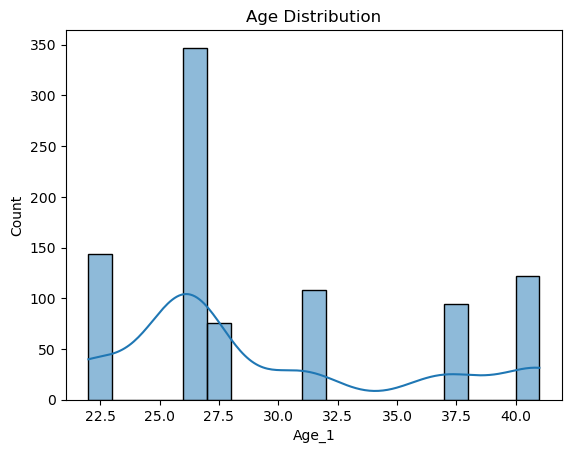

In [14]:
# **Step 3: Exploratory Data Analysis (EDA)**
# Visualize distribution of Age
sns.histplot(train_df['Age_1'], kde=True)
plt.title('Age Distribution')
plt.show()

In [15]:
train_df.groupby(['Embarked_S'], as_index=False)['Survived'].mean()

,Embarked_S,Survived
0,0,0.502041
1,1,0.339009


In [16]:
train_df.groupby(['Embarked_C'], as_index=False)['Survived'].mean()

,Embarked_C,Survived
0,0,0.344398
1,1,0.553571


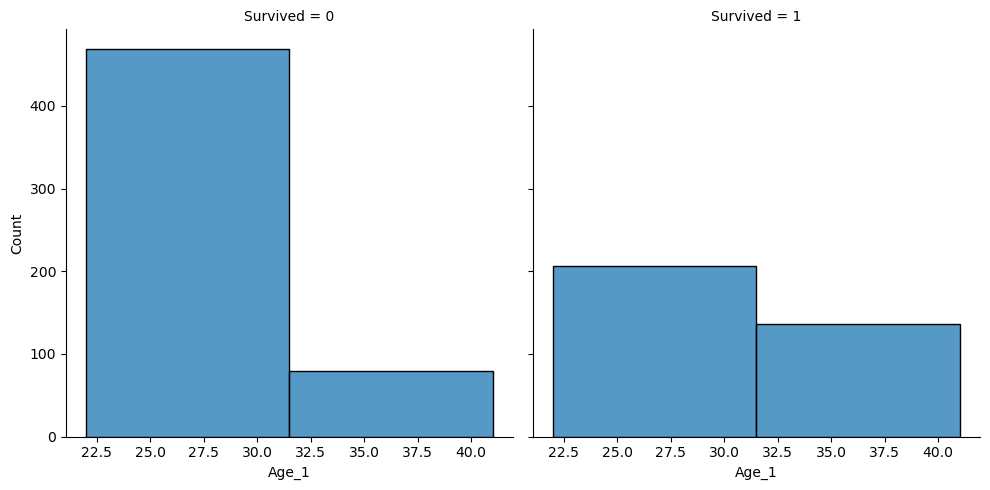

In [17]:
sns.displot(train_df, x='Age_1', col='Survived', binwidth=10, height=5)

# Show plot
plt.show()

In [18]:
train_df['Age_Cut'] = pd.qcut(train_df['Age_1'], q=5, duplicates='drop')
test_df['Age_Cut'] = pd.qcut(test_df['Age_1'], q=5, duplicates='drop')

train_df.groupby(['Age_Cut'], as_index=False, observed=False)['Survived'].mean()


,Age_Cut,Survived
0,"(21.999, 26.0]",0.242363
1,"(26.0, 27.0]",0.921053
2,"(27.0, 37.0]",0.534653
3,"(37.0, 41.0]",0.368852


In [19]:
train_df.loc[train_df['Age_1'] <= 19, 'Age_1'] = 0
train_df.loc[(train_df['Age_1'] > 19) & (train_df['Age_1'] <= 25), 'Age_1'] = 1
train_df.loc[(train_df['Age_1'] > 25) & (train_df['Age_1'] <= 31.8), 'Age_1'] = 2
train_df.loc[(train_df['Age_1'] > 31.8) & (train_df['Age_1'] <= 41), 'Age_1'] = 3
train_df.loc[(train_df['Age_1'] > 41) & (train_df['Age_1'] <= 80), 'Age_1'] = 4
train_df.loc[train_df['Age_1'] > 80, 'Age_1'] 

test_df.loc[test_df['Age_1'] <= 19, 'Age_1'] = 0
test_df.loc[(test_df['Age_1'] > 19) & (test_df['Age_1'] <= 25), 'Age_1'] = 1
test_df.loc[(test_df['Age_1'] > 25) & (test_df['Age_1'] <= 31.8),'Age_1'] = 2
test_df.loc[(test_df['Age_1'] > 31.8) & (test_df['Age_1'] <= 41), 'Age_1'] = 3
test_df.loc[(test_df['Age_1'] > 41) & (test_df['Age_1'] <= 80), 'Age_1'] = 4
test_df.loc[test_df['Age_1'] > 80, 'Age_1'] 

Series([], Name: Age_1, dtype: int64)

In [20]:
train_df.head()

,PassengerId,Survived,Pclass,Fare_1,Age_1,Family,Sex_1,IsAlone,Title_Mr,Title_Mrs,...,Ticket_SWPP,Ticket_PPP,Ticket_SC,Ticket_SCAH,Ticket_SOPP,Ticket_FC,Ticket_SOTONO2,Family_Size,Family_Size_Grouped,Age_Cut
0,1,0,3,7.2500,2,2,1,0,1,0,...,0,0,0,0,0,0,0,3,Small,"(21.999, 26.0]"
1,2,1,1,71.2833,3,2,0,0,0,1,...,0,0,0,0,0,0,0,3,Small,"(27.0, 37.0]"
2,3,1,3,7.9250,1,1,0,1,0,0,...,0,0,0,0,0,0,0,3,Small,"(21.999, 26.0]"
3,4,1,1,53.1000,3,2,0,0,0,1,...,0,0,0,0,0,0,0,3,Small,"(27.0, 37.0]"
4,5,0,3,8.0500,2,1,1,1,1,0,...,0,0,0,0,0,0,0,3,Small,"(21.999, 26.0]"


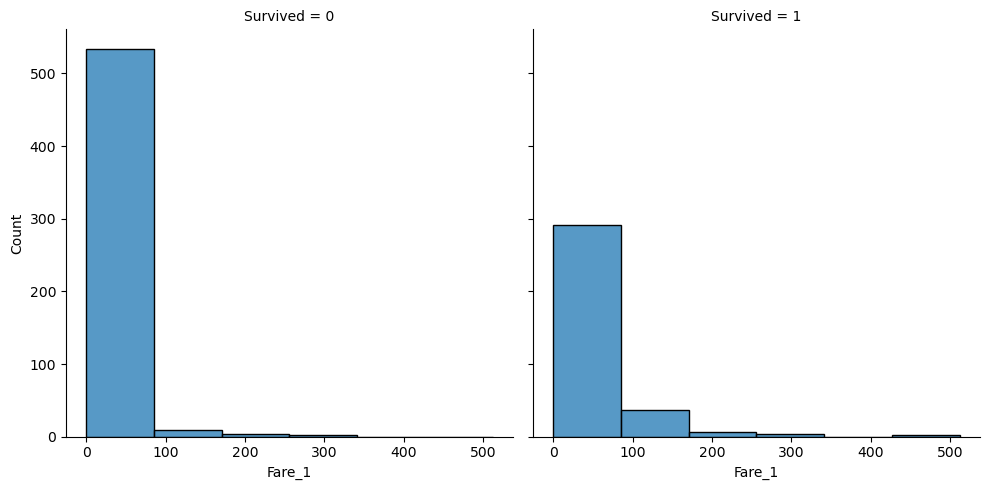

In [21]:
sns.displot(train_df, x='Fare_1', col='Survived', binwidth=80, height=5)

# Show plot
plt.show()

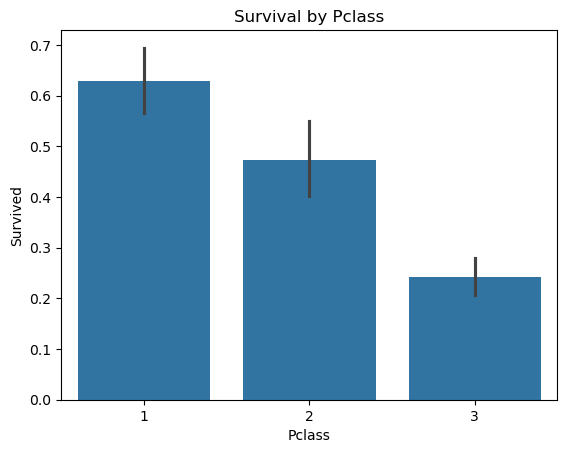

In [22]:
# Visualize survival rates by 'Pclass' and 'Sex'
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Survival by Pclass')
plt.show()

In [23]:
train_df['Fare_Cut'] = pd.qcut(train_df['Fare_1'], 5)
test_df['Fare_Cut'] = pd.qcut(test_df['Fare_1'], 5)

train_df.groupby(['Fare_Cut'], as_index=False, observed=False)['Survived'].mean()


,Fare_Cut,Survived
0,"(-0.001, 7.854]",0.217877
1,"(7.854, 10.5]",0.201087
2,"(10.5, 21.679]",0.424419
3,"(21.679, 39.688]",0.444444
4,"(39.688, 512.329]",0.642045


In [24]:
# Train-Test Split
# Define features and target variable
X = train_df[['Pclass', 'Sex_1', 'Age_1', 'Fare_1', 'Family_Size', 'Embarked_C', 'Embarked_S']]
y = train_df['Survived']

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Train the Model**
# Use Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [26]:
# Evaluate the Model
# Make predictions on the validation set
y_pred = model.predict(X_val)

Accuracy Score: 0.7988826815642458
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



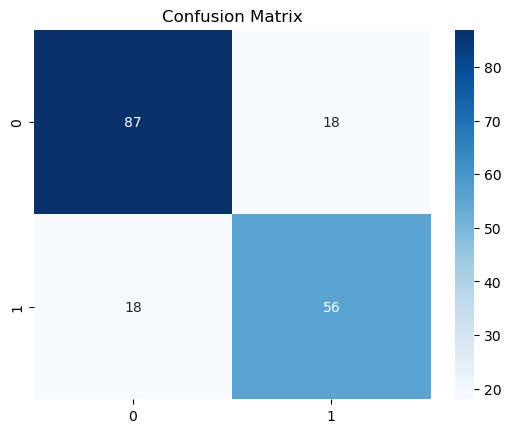

In [27]:
# Print classification report and confusion matrix
print("Accuracy Score:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [28]:
# Convert 'Embarked' to numeric (using pd.get_dummies for one-hot encoding)
train_df = pd.get_dummies(train_df, columns=['Embarked_C'], drop_first=True)

In [29]:
# Convert 'Embarked' to numeric (using pd.get_dummies for one-hot encoding)
train_df = pd.get_dummies(train_df, columns=['Embarked_S'], drop_first=True)

In [30]:
# Convert 'Sex' to numeric (0 for female, 1 for male)
train_df['Sex_1'] = train_df['Sex_1'].map({'female': 0, 'male': 1})

In [31]:
# Create a deep copy of the required columns from test_df to avoid the SettingWithCopyWarning
X_test = test_df[['Pclass', 'Sex_1', 'Age_1', 'Fare_1', 'Family_Size']].copy()

# Check if the 'Embarked_C' and 'Embarked_S' columns exist in test_df; if not, create them
if 'Embarked_C' not in test_df.columns:
    test_df['Embarked_C'] = 0
if 'Embarked_S' not in test_df.columns:
    test_df['Embarked_S'] = 0

# Now, modify the columns in X_test using .loc[] to avoid the warning
X_test.loc[:, 'Embarked_C'] = test_df['Embarked_C']
X_test.loc[:, 'Embarked_S'] = test_df['Embarked_S']






In [32]:
print(list(test_df.columns))

['PassengerId', 'Pclass', 'Fare_1', 'Age_1', 'Family', 'Sex_1', 'IsAlone', 'Title_Mr', 'Title_Mrs', 'Title_Miss', 'Title_Master', 'Embarked_S', 'Embarked_C', 'Cabin_M', 'Cabin_C', 'Cabin_E', 'Cabin_G', 'Cabin_D', 'Cabin_A', 'Cabin_B', 'Cabin_F', 'Ticket_A5 ', 'Ticket_PC ', 'Ticket_STONO2 ', 'Ticket_xxx\xa0 ', 'Ticket_PP ', 'Ticket_CA ', 'Ticket_SCParis ', 'Ticket_SCA4 ', 'Ticket_A4 ', 'Ticket_SOC ', 'Ticket_WC ', 'Ticket_SOTONOQ ', 'Ticket_WEP ', 'Ticket_STONO ', 'Ticket_C ', 'Ticket_LINE', 'Ticket_FCC ', 'Ticket_SWPP ', 'Ticket_PPP ', 'Ticket_SC ', 'Ticket_SCAH ', 'Ticket_SOPP ', 'Ticket_FC ', 'Ticket_SOTONO2 ', 'Family_Size', 'Family_Size_Grouped', 'Age_Cut', 'Fare_Cut']


In [33]:
test_df.rename(columns={'Embarked_C': 'Embarked_C_1', 'Embarked_S': 'Embarked_S_1'}, inplace=True)


In [34]:
# Predict on Test Data
# Apply the same feature engineering to the test set
test_df['Sex_1'] = test_df['Sex_1'].map({'female': 0, 'male': 1})
if 'Embarked' in test_df.columns:
    test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True)
else:
    print("Warning: 'Embarked' column is missing from test_df")
test_df['Family_Size'] = test_df['Family'] + test_df['IsAlone'] + 1

X_test = test_df[['Pclass', 'Sex_1', 'Age_1', 'Fare_1', 'Family_Size', 'Embarked_C_1', 'Embarked_S_1']]



In [35]:
print("Train Features:", model.feature_names_in_)
print("Test Features:", X_test.columns)


Train Features: ['Pclass' 'Sex_1' 'Age_1' 'Fare_1' 'Family_Size' 'Embarked_C' 'Embarked_S']
Test Features: Index(['Pclass', 'Sex_1', 'Age_1', 'Fare_1', 'Family_Size', 'Embarked_C_1',
       'Embarked_S_1'],
      dtype='object')


In [36]:
X_test = X_test.rename(columns={'Embarked_C_1': 'Embarked_C', 'Embarked_S_1': 'Embarked_S'})


In [37]:
print("Updated Test Features:", X_test.columns)


Updated Test Features: Index(['Pclass', 'Sex_1', 'Age_1', 'Fare_1', 'Family_Size', 'Embarked_C',
       'Embarked_S'],
      dtype='object')


In [38]:
# Predict on test data
test_predictions = model.predict(X_test)

# Create a DataFrame with predictions
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})


In [39]:
# Save the predictions to a CSV file
submission.to_csv('titanic_predictions.csv', index=False)
print("Predictions saved to 'titanic_predictions.csv'")

Predictions saved to 'titanic_predictions.csv'


In [40]:
ohe = OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy='most_frequent')

In [41]:
ode_cols = ['Family_Size_Grouped']
ohe_cols = ['Sex_1', 'Embarked']

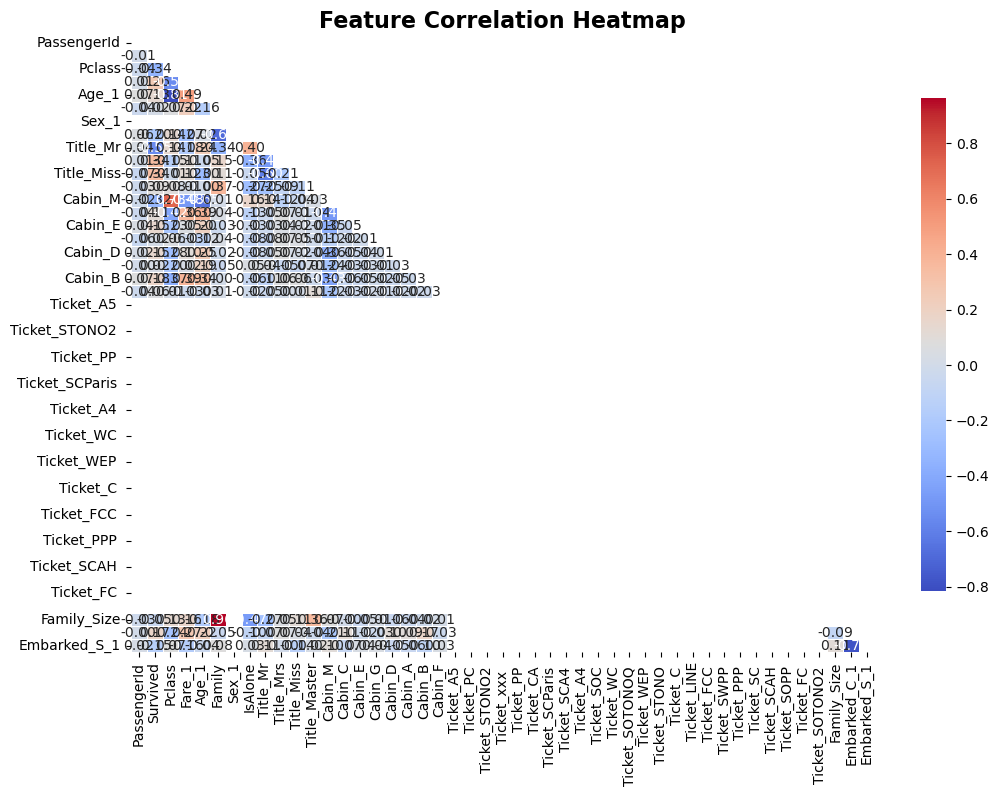

In [42]:
# Compute correlation matrix
correlation_matrix = train_df.corr(numeric_only=True)

# Create a mask for the upper triangle (to remove duplicate values)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set figure size for better readability
plt.figure(figsize=(12, 8))

# Create heatmap with enhancements
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    mask=mask,  # Apply mask
    annot_kws={"size": 10},  # Adjust annotation font size
    cbar_kws={"shrink": 0.8}  # Shrink color bar for better fit
)

# Add title with styling
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')

# Show plot
plt.show()

In [43]:
print(train_df['Age_1'].isnull().sum())  # Count missing values

0
